# Time Series and Row Indexing with Pandas

Welcome to Session 6. In Session 5, you loaded, inspected, filtered, summarized, and visualized data. In this session, we will make dates the row labels of a time-series DataFrame and use those labels to select observations.

**Estimated time:** 60 minutes

**Dataset:** FRED series CPILFESL, Consumer Price Index for All Urban Consumers: All Items Less Food and Energy in U.S. City Average. The CPI is an index, not a dollar price. A percent change in the index is one way to describe inflation over a chosen period; index-point changes and percent changes are different quantities.

By the end, you will be able to parse dates while loading a CSV, set and inspect a `DatetimeIndex`, select rows by date labels with `.loc`, select rows by position with `.iloc`, slice time periods, calculate changes across time, and summarize monthly observations by year.

## 1. Load the CPI series (5 minutes)

First import the tools and locate the CSV. Depending on where Jupyter starts, the file may be in the current folder or its parent. The code checks both locations, then parses the observation dates and uses them as the index during import.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_candidates = [
    Path('CPILFESL.csv'),
    Path('../CPILFESL.csv'),
    Path('data/CPILFESL.csv'),
    Path('../data/CPILFESL.csv'),
]
csv_path = next((path for path in csv_candidates if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Place CPILFESL.csv beside the notebook or in the project folder.')

cpi = pd.read_csv(
    csv_path,
    parse_dates=['observation_date'],
    index_col='observation_date',
).rename(columns={'CPILFESL': 'cpi'})

print('Loaded:', csv_path.resolve())
cpi.head()

Loaded: /workspaces/codespaces-jupyter/CPILFESL.csv


,cpi
observation_date,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


## 2. Inspect the series and its index (7 minutes)

As in Session 5, check the shape, data types, beginning, and end of the dataset. Then look closely at the index. A `DatetimeIndex` stores the dates as labels, which lets pandas select rows using calendar dates rather than only row numbers.

In [2]:
print('Rows and columns:', cpi.shape)
print('Index type:', type(cpi.index).__name__)
print('Index name:', cpi.index.name)
print('Column names:', cpi.columns.tolist())
print('First date:', cpi.index.min())
print('Last date:', cpi.index.max())
print('Dates ordered:', cpi.index.is_monotonic_increasing)
print('Dates unique:', cpi.index.is_unique)
cpi.info()

Rows and columns: (836, 1)
Index type: DatetimeIndex
Index name: observation_date
Column names: ['cpi']
First date: 1957-01-01 00:00:00
Last date: 2026-08-01 00:00:00
Dates ordered: True
Dates unique: True
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 836 entries, 1957-01-01 to 2026-08-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cpi     835 non-null    float64
dtypes: float64(1)
memory usage: 13.1 KB


In [3]:
print('Beginning of series')
display(cpi.head())
print('End of series')
display(cpi.tail())
print('Inferred date frequency:', pd.infer_freq(cpi.index))

Beginning of series


,cpi
observation_date,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


End of series


,cpi
observation_date,
2026-04-01,335.423
2026-05-01,336.121
2026-06-01,336.065
2026-07-01,336.789
2026-08-01,337.765


Inferred date frequency: MS


### Check for missing values

This file contains a missing CPI value even though its date is present. Finding a missing value is not the same as deciding how to handle it. We will leave it missing; filling it with a nearby value would change the data and could distort later calculations.

In [4]:
print('Missing values by column:')
display(cpi.isna().sum())
print('Rows with a missing CPI value:')
cpi.loc[cpi['cpi'].isna()]

Missing values by column:


cpi    1
dtype: int64

Rows with a missing CPI value:


,cpi
observation_date,
2025-10-01,NaN


## 3. Row labels are not row numbers (8 minutes)

A DataFrame index gives each row a label. In this notebook the labels are dates. The index is separate from the data columns: `cpi.index` holds the dates, and `cpi['cpi']` holds the CPI values.

Two selection tools to remember:

- `.loc[...]` selects using **labels**, such as a date.
- `.iloc[...]` selects using **integer positions**, starting at zero.

An integer position answers “which row in the current ordering?” A date label answers “which observation date?” If rows are filtered or reordered, positions may change while date labels remain attached to their observations.

In [5]:
print('First three date labels:')
print(cpi.index[:3])
print('First three rows by position:')
cpi.iloc[:3]

First three date labels:
DatetimeIndex(['1957-01-01', '1957-02-01', '1957-03-01'], dtype='datetime64[ns]', name='observation_date', freq=None)
First three rows by position:


,cpi
observation_date,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7


### Select by position with `.iloc`

Use `.iloc` when you mean a row's place in the current table. Like ordinary Python slicing, the stop position is excluded. The row at position 0 is the first observation; position -1 is the last observation.

In [6]:
print('First row:')
display(cpi.iloc[0])
print('Last row:')
display(cpi.iloc[-1])
print('Positions 0 through 4 (stop 5 is excluded):')
cpi.iloc[0:5]

First row:


cpi    28.5
Name: 1957-01-01 00:00:00, dtype: float64

Last row:


cpi    337.765
Name: 2026-08-01 00:00:00, dtype: float64

Positions 0 through 4 (stop 5 is excluded):


,cpi
observation_date,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


### Select by date label with `.loc`

Use `.loc` when you know the observation date. A string in ISO format is convenient for a date label. With one exact date, pandas returns the row for that date.

In [7]:
cpi.loc['2020-01-01']

cpi    266.716
Name: 2020-01-01 00:00:00, dtype: float64

### Practice 1: Labels or positions?

Before running the next cell, predict which observation each expression selects. Then run the cell and explain why the dates differ. What changes if you first select only dates from 2020 onward and then run `.iloc[0]`?

In [8]:
display(cpi.loc['1982-01-01'])
display(cpi.iloc[0])
display(cpi.loc[cpi.index >= '2020-01-01'].iloc[0])

cpi    93.3
Name: 1982-01-01 00:00:00, dtype: float64

cpi    28.5
Name: 1957-01-01 00:00:00, dtype: float64

cpi    266.716
Name: 2020-01-01 00:00:00, dtype: float64

### Select one value or specific rows and columns

For one scalar value, `.at` uses a row label and column name; `.iat` uses row and column positions. `.loc` can also select a range of row labels and a subset of columns. These methods make the row and column choices explicit.

In [9]:
print('CPI at the January 2020 date label:', cpi.at[pd.Timestamp('2020-01-01'), 'cpi'])
print('CPI at row position 0, column position 0:', cpi.iat[0, 0])
print('Selected dates and the CPI column:')
cpi.loc['2020-01-01':'2020-06-01', ['cpi']]

CPI at the January 2020 date label: 266.716
CPI at row position 0, column position 0: 28.5
Selected dates and the CPI column:


,cpi
observation_date,
2020-01-01,266.716
2020-02-01,267.370
2020-03-01,267.054
2020-04-01,265.746
2020-05-01,265.412
2020-06-01,265.849


## 4. Slice time by date labels (8 minutes)

With a `DatetimeIndex`, `.loc` can select a date range. Both ends of a label-based date slice are included. A partial date string such as `'2020'` selects all available observations in that year. Compare the results with `.iloc[:12]`, which selects the first 12 rows regardless of the years they represent.

In [11]:
cpi_2020 = cpi.loc['2020']
print('Rows selected by the partial date label:', len(cpi_2020))
display(cpi_2020)
print('First 12 rows by position:')
display(cpi.iloc[:12])

Rows selected by the partial date label: 12


,cpi
observation_date,
2020-01-01,266.716
2020-02-01,267.370
2020-03-01,267.054
2020-04-01,265.746
2020-05-01,265.412
2020-06-01,265.849
2020-07-01,267.389
2020-08-01,268.422
2020-09-01,268.933


First 12 rows by position:


,cpi
observation_date,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8
1957-06-01,28.9
1957-07-01,29.0
1957-08-01,29.0
1957-09-01,29.1


### Combine date ranges with conditions

`.loc` can select rows using a Boolean condition and then select columns. The result keeps the original date labels. Here we select dates in a period where CPI is above a chosen threshold. A threshold is a way to practice filtering, not a claim that one value is inherently good or bad.

In [12]:
period = cpi.loc['2020-01-01':'2022-12-01']
above_threshold = period.loc[period['cpi'] > 280, ['cpi']]
above_threshold.head()

,cpi
observation_date,
2021-10-01,281.668
2021-11-01,283.406
2021-12-01,285.180
2022-01-01,286.757
2022-02-01,288.273


### Practice 2: Explore a chosen period

Use `.loc` to select all observations from 2010 through 2014, inclusive. Then use `.iloc` to display the first three rows of that slice. How many observations are in the date slice, and what date labels do the first three rows have?

In [13]:
period_2010s = cpi.loc['2010-01-01':'2014-12-01']
print('Number of rows:', len(period_2010s))
period_2010s.iloc[:3]

Number of rows: 60


,cpi
observation_date,
2010-01-01,220.633
2010-02-01,220.731
2010-03-01,220.783


## 5. Compare observations across time (8 minutes)

In Session 5, `.diff()` compared adjacent rows. With monthly observations sorted by date, this gives the change from the previous month. `.shift(1)` moves the previous month's value down one row so you can inspect the pair side by side. The first observation has no previous month, so its change is missing.

In [14]:
cpi['previous_month'] = cpi['cpi'].shift(1)
cpi['change_from_previous_month'] = cpi['cpi'].diff()
cpi.loc['2020-01-01':'2020-06-01']

,cpi,previous_month,change_from_previous_month
observation_date,,,
2020-01-01,266.716,266.020,0.696
2020-02-01,267.370,266.716,0.654
2020-03-01,267.054,267.370,-0.316
2020-04-01,265.746,267.054,-1.308
2020-05-01,265.412,265.746,-0.334
2020-06-01,265.849,265.412,0.437


### Calculate percent changes

`.pct_change()` calculates a relative change. Multiply by 100 to express it as a percent. For year-over-year change, compare with the observation 12 rows earlier. We use `fill_method=None` so pandas does not fill missing values automatically. The missing CPI observation in October 2025 means some changes that depend on it will also be missing; that is expected.

In [15]:
cpi['monthly_change_pct'] = cpi['cpi'].pct_change(fill_method=None) * 100
cpi['year_over_year_pct'] = cpi['cpi'].pct_change(periods=12, fill_method=None) * 100
cpi.loc['2020-01-01':'2020-06-01', ['cpi', 'change_from_previous_month', 'monthly_change_pct', 'year_over_year_pct']]

,cpi,change_from_previous_month,monthly_change_pct,year_over_year_pct
observation_date,,,,
2020-01-01,266.716,0.696,0.261634,2.281739
2020-02-01,267.370,0.654,0.245205,2.367661
2020-03-01,267.054,-0.316,-0.118188,2.097742
2020-04-01,265.746,-1.308,-0.489789,1.430932
2020-05-01,265.412,-0.334,-0.125684,1.218456
2020-06-01,265.849,0.437,0.164650,1.183684


### Smooth short-term movement with a rolling mean

A rolling mean summarizes a fixed number of adjacent observations. A 12-row rolling mean of monthly data uses 12 months. Setting `min_periods=12` requires a complete 12-value window; windows that include the missing CPI observation remain missing rather than silently using fewer values.

In [16]:
cpi['rolling_12_month_mean'] = cpi['cpi'].rolling(window=12, min_periods=12).mean()
cpi.loc['2020-01-01':'2020-06-01', ['cpi', 'rolling_12_month_mean']]

,cpi,rolling_12_month_mean
observation_date,,
2020-01-01,266.716,263.708750
2020-02-01,267.370,264.224083
2020-03-01,267.054,264.681333
2020-04-01,265.746,264.993750
2020-05-01,265.412,265.260000
2020-06-01,265.849,265.519167


## 6. Resample monthly observations by year (6 minutes)

`.resample()` groups a time-indexed series into calendar periods. For example, `'YS'` starts a new group at the beginning of each year. Taking the mean summarizes the monthly values as an annual average. This is different from selecting a single month with `.loc` and different from taking only the last month of each year.

In [17]:
annual_cpi = cpi['cpi'].resample('YS').agg(['mean', 'min', 'max', 'count'])
annual_cpi.tail(10)

,mean,min,max,count
observation_date,,,,
2017-01-01,252.152500,250.467,254.344,12
2018-01-01,257.561417,255.204,260.063,12
2019-01-01,263.212917,260.766,266.020,12
2020-01-01,267.709917,265.412,270.341,12
2021-01-01,277.251000,270.387,285.180,12
2022-01-01,294.306667,286.757,301.394,12
2023-01-01,308.378583,302.642,313.195,12
2024-01-01,318.989833,314.319,323.259,12
2025-01-01,328.042545,324.638,331.814,11


## 7. Visualize the series with dates (6 minutes)

Because the index contains dates, Matplotlib can use it directly on the horizontal axis. The first chart shows monthly index values with a 12-month rolling mean. The second shows year-over-year percent changes. Remember: the CPI level is an index, while the percent-change chart is a rate of change over the previous 12 months.

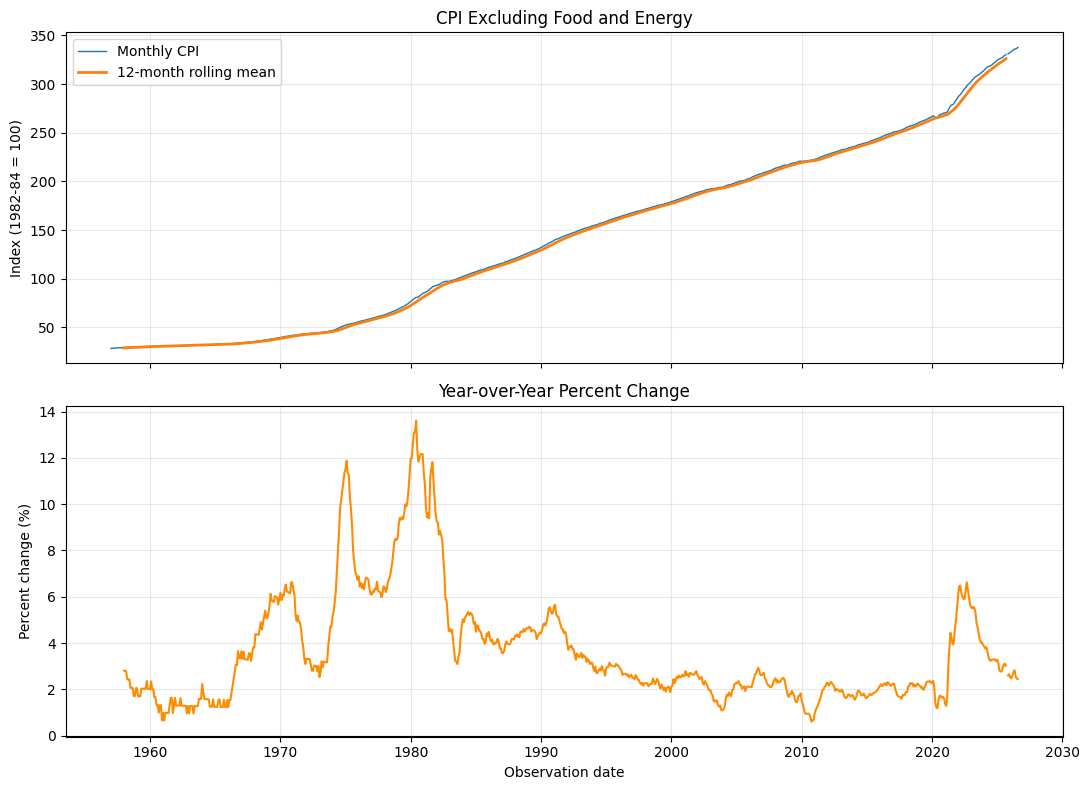

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(cpi.index, cpi['cpi'], label='Monthly CPI', linewidth=1)
axes[0].plot(cpi.index, cpi['rolling_12_month_mean'], label='12-month rolling mean', linewidth=2)
axes[0].set_title('CPI Excluding Food and Energy')
axes[0].set_ylabel('Index (1982-84 = 100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cpi.index, cpi['year_over_year_pct'], color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year Percent Change')
axes[1].set_xlabel('Observation date')
axes[1].set_ylabel('Percent change (%)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Mini-project: answer with date labels (6 minutes)

Use `.loc` to investigate the CPI series and answer these questions in your own words:

1. What is the CPI value for January 2020?
2. What were the first and last monthly CPI values in 2020? What is the index-point difference between them?
3. What was the year-over-year percent change at the end of 2020?
4. How many non-missing CPI observations are in 2025?
5. Use `.iloc` to show the final five rows, then explain why `.loc` is usually clearer when you want a known date.

Try your own code before looking at the example solution in the next cell. Changes in this index describe this series; they do not identify the causes of changes or predict future values.

In [ ]:
# Write your solution here. Start by selecting 2020 with .loc.

### Example solution

Run this after attempting the questions. Compare your answers and adapt the code to investigate a different year.

In [ ]:
year_2020 = cpi.loc['2020']
print('January 2020 CPI:', year_2020.loc['2020-01-01', 'cpi'])
first_value = year_2020.iloc[0]['cpi']
last_value = year_2020.iloc[-1]['cpi']
print('First and last 2020 CPI:', first_value, last_value)
print('Index-point difference:', last_value - first_value)
print('Year-over-year change at end of 2020 (%):', year_2020.iloc[-1]['year_over_year_pct'])
print('Non-missing CPI observations in 2025:', cpi.loc['2025', 'cpi'].count())
cpi.iloc[-5:]

## Recap

A time-series index makes dates usable as row labels. Use `.loc` to ask for a particular date or date range, and `.iloc` to ask for rows by their current position. `.diff()`, `.pct_change()`, `.rolling()`, and `.resample()` help summarize change and patterns across time. Preserve missing observations unless you have a reasoned method for handling them, and describe index levels separately from percent changes.